In [1]:
%load_ext autoreload
%autoreload 2

In [63]:
from the_well.data import WellDataset
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import torch
from einops import rearrange
import equinox as eqx
import jax.tree_util as jtu

from utils import prepare_batch

In [64]:
dataset_path = "datasets/llg_field_switching"
IN_CONTEXT_N = 1

dataset = WellDataset(
    path=dataset_path,
    well_split_name="train",
    n_steps_input=IN_CONTEXT_N,
    n_steps_output=1,
    use_normalization=False,
)

In [65]:
for k, v in dataset[2].items():
    print(k, v.shape)

input_fields torch.Size([1, 256, 256, 3])
output_fields torch.Size([1, 256, 256, 3])
constant_scalars torch.Size([6])
boundary_conditions torch.Size([2, 2])
space_grid torch.Size([256, 256, 2])
input_time_grid torch.Size([1])
output_time_grid torch.Size([1])


In [68]:
loader = DataLoader(dataset=dataset, batch_size=8, shuffle=True)
batch = next(iter(loader))

m0, m1, c = prepare_batch(batch=batch, pool=4)

m0.shape

(8, 5, 64, 64)

In [71]:
m = m0[0, 0]
m.shape

(64, 64)

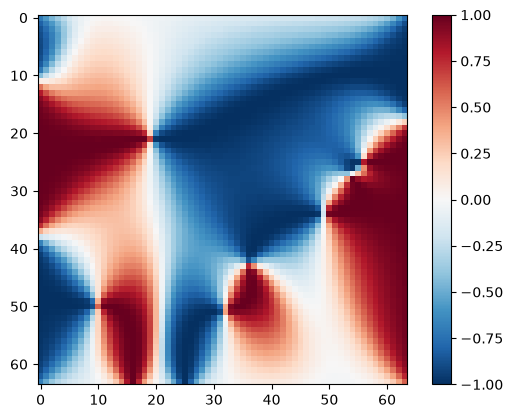

In [ ]:
im = plt.imshow(m, vmin=-1, vmax=1, cmap="RdBu_r")
plt.colorbar(im)